[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/czh4ng/DASNet-workshop/blob/main/notebooks/lab2d_dasnet_inference.ipynb)

# Lab 2d: DASNet Inference

In this lab, you will learn how to:
- Load one Monterey Bay DAS tile from Hugging Face (**AI4EPS/quakeflow_das**), same flow as Lab 2a;
- Run DASNet for detection, classification, masks, and arrival-oriented picks;
- Inspect saved JSON and quicklook figures;
- Optionally run the same pipeline through predict.py from the shell.

**References:**
- Zhang, C., et al. (2026). "A deep learning framework for marine acoustic and seismic monitoring with distributed acoustic sensing." [arXiv:2603.14844](https://arxiv.org/abs/2603.14844).
- Romanowicz, B., et al. (2023). "SeaFOAM: A year‐long DAS deployment in Monterey Bay, California." *SRL*, 94(5), 2348-2359.

---


## Setup


In [10]:
import os
import subprocess

REPO_URL = "https://github.com/czh4ng/DASNet-workshop.git"
WORK_DIR = os.path.abspath(os.path.join(os.getcwd(), "DASNet-workshop"))

if not os.path.isdir(WORK_DIR):
    subprocess.run(["git", "clone", REPO_URL, WORK_DIR], check=True)
    print("Cloned to:", WORK_DIR)
else:
    print("Directory already exists:", WORK_DIR)

os.chdir(WORK_DIR)
print("cwd:", os.getcwd())


Cloned to: /content/DASNet-workshop/DASNet-workshop
cwd: /content/DASNet-workshop/DASNet-workshop


In [11]:
%pip install -q -r requirements.txt
%pip install -q huggingface_hub


In [12]:
import csv
import json
import subprocess
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import urllib.request
from IPython.display import Image, display
from huggingface_hub import hf_hub_download

%matplotlib inline

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DS_PLOT = 2


def plot_das(ax, arr_ch_by_time, dt_s=None, **kwargs):
    arr = np.asarray(arr_ch_by_time)
    extent = None
    if dt_s is not None:
        nt = arr.shape[1]
        extent = [0, nt * float(dt_s), arr.shape[0], 0]
    ax.imshow(
        arr[::DS_PLOT, ::DS_PLOT],
        aspect="auto",
        interpolation="bilinear",
        extent=extent,
        **kwargs,
    )


def _to_numpy_pred(d):
    return {k: (v.detach().cpu().numpy() if torch.is_tensor(v) else v) for k, v in d.items()}


Device: cuda


## 1. Load DAS Data

We use DAS data from **SeaFOAM** in Monterey Bay, California (Romanowicz et al., 2023). **DASNet** was trained on SeaFOAM. The deployment uses a ~52 km fiber with 5.2 m channel spacing at 200 Hz sampling.

Shallow parts of the cable are dominated by cultural and sea-surface noise, so we focus on the **deep-water** section (channel index > 7400).

Each workshop tile is an HDF5 file containing a 2D array of shape (nx, nt) — channels by time — plus metadata for the sample interval.

Set **EVENT_ID** in the next cell. The following figure shows **raw strain rate**, **2–10 Hz bandpass**, and **>10 Hz highpass**.


In [13]:
HF_REPO = "AI4EPS/quakeflow_das"
EVENT_ID = "20231109T132510Z"

h5_path = hf_hub_download(
    HF_REPO,
    f"monterey_bay/data/{EVENT_ID}.h5",
    repo_type="dataset",
    local_dir="data/quakeflow_das",
)
SELECTED_H5 = str(Path(h5_path).resolve())
print("Cached path:", SELECTED_H5)

with h5py.File(SELECTED_H5, "r") as fp:
    data = fp["data"][:]
    attrs = dict(fp["data"].attrs)

dt_s = float(attrs.get("dt_s"))
begin_time = str(attrs.get("begin_time", ""))
nx, nt = data.shape
das_arr = data.astype(np.float32)

print(f"Event: {EVENT_ID}")
print(f"Shape: (nx={nx}, nt={nt})")
print(f"Sampling interval: {dt_s} s ({1/dt_s:.0f} Hz)")
print(f"Duration: {nt * dt_s:.1f} s")
if begin_time:
    print(f"Begin time: {begin_time}")


monterey_bay/data/20231109T132510Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

Cached path: /content/DASNet-workshop/DASNet-workshop/data/quakeflow_das/monterey_bay/data/20231109T132510Z.h5
Event: 20231109T132510Z
Shape: (nx=2845, nt=12000)
Sampling interval: 0.005000114440917969 s (200 Hz)
Duration: 60.0 s
Begin time: 2023-11-09T13:25:10.000000+00:00


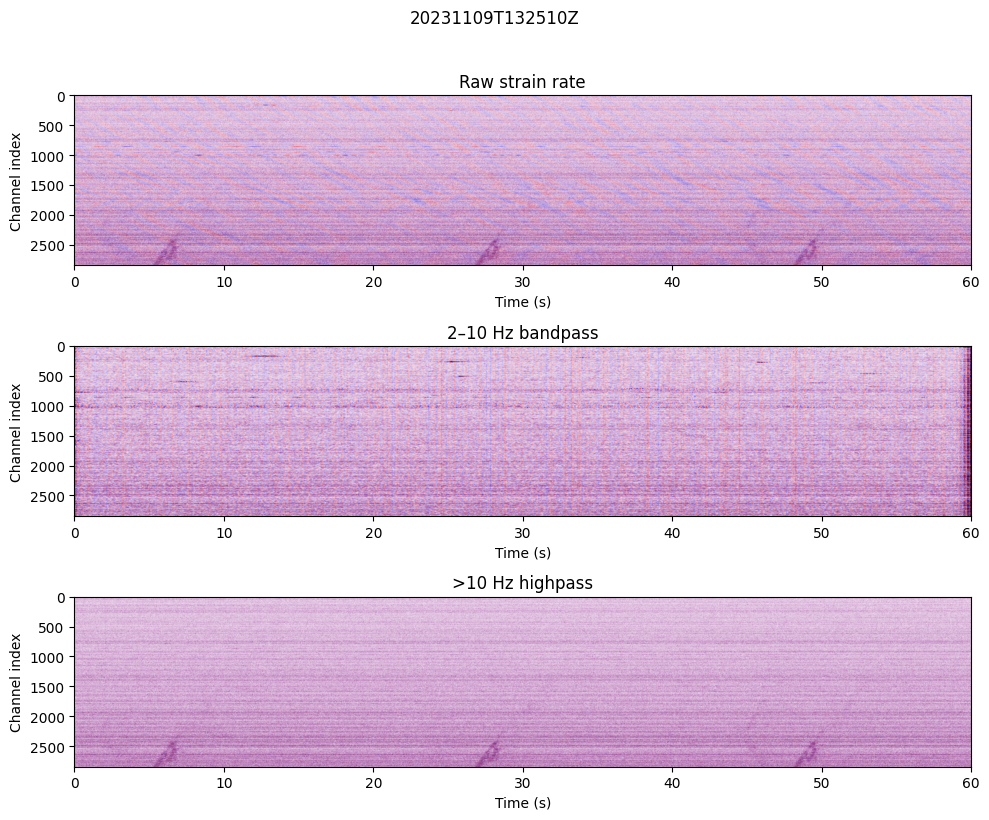

In [14]:
from scipy.signal import sosfiltfilt

from dasnet.data import das as das_das

sos_bp = das_das._safe_design_sos_bandpass(dt_s, 2.0, 10.0, order=4)
sos_hp = das_das._safe_design_sos_highpass(dt_s, 10.0, order=4)
das_bp = sosfiltfilt(sos_bp, das_arr, axis=1).astype(np.float32)
das_hp = sosfiltfilt(sos_hp, das_arr, axis=1).astype(np.float32)

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

titles = [
    "Raw strain rate",
    "2–10 Hz bandpass",
    ">10 Hz highpass",
]
arrays = [das_arr, das_bp, das_hp]

for ax, arr, title in zip(axes, arrays, titles):
    v = 2 * float(np.percentile(np.abs(arr), 95))
    plot_das(ax, arr, dt_s=dt_s, cmap="seismic", vmin=-v, vmax=v)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Channel index")

fig.suptitle(f"{EVENT_ID}", y=1.02)
plt.tight_layout()
plt.show()


## 2. Run DASNet

DASNet outputs a class, confidence, box, and soft mask per detection; peaks along the mask summarize arrivals where applicable. The next cell downloads the workshop checkpoint, runs the **selected** tile (**EVENT_ID** above) through the model, and saves JSON plus a figure under pred_notebook/.


In [15]:
CKPT_URL = "https://github.com/czh4ng/DASNet-workshop/releases/download/v0.1.1/checkpoint.pth"
CKPT_PATH = Path(WORK_DIR) / "checkpoint.pth"
if not CKPT_PATH.exists():
    urllib.request.urlretrieve(CKPT_URL, CKPT_PATH)

from lab2d_inference_helpers import (
    build_dasnet_model,
    default_device,
    extract_peaks_for_instances,
    filter_by_score,
    forward_raw,
    load_checkpoint,
    make_infer_dataloader,
    plot_das_predictions,
    postprocess_batch,
    save_predictions_json,
)

RESIZE_SCALE = 0.5
MIN_PROB = 0.8

device = default_device()
model = build_dasnet_model()
load_checkpoint(model, str(CKPT_PATH), device)

loader, _ = make_infer_dataloader(
    [SELECTED_H5],
    batch_size=1,
    num_workers=0,
    resize_scale=RESIZE_SCALE,
    storage_backend="local",
)
images, names = next(iter(loader))

raw_outputs = forward_raw(model, list(images), device)
_, processed = postprocess_batch(names, raw_outputs)
p0 = processed[0]
selected = filter_by_score(p0, MIN_PROB)
peak_points_list, peak_scores_list = extract_peaks_for_instances(selected)

RESULT_DIR = Path(WORK_DIR) / "pred_notebook"
FIG_DIR = RESULT_DIR / "figures_dasnet"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

fn0 = names[0]
save_predictions_json(
    fn0,
    _to_numpy_pred(selected),
    peak_points_list,
    peak_scores_list,
    str(RESULT_DIR),
    resize_scale=RESIZE_SCALE,
)
fig_path = FIG_DIR / (Path(fn0).stem + ".jpg")
plot_das_predictions(
    images[0].cpu().numpy(),
    _to_numpy_pred(selected),
    str(fig_path),
    score_threshold=MIN_PROB,
)

print("Instances kept:", len(selected["scores"]), "| JSON + figure →", RESULT_DIR)


Instances kept: 6 | JSON + figure → /content/DASNet-workshop/DASNet-workshop/pred_notebook


## 3. Check output

Open the quicklook figure and JSON for the **same** tile as **EVENT_ID** / Run DASNet. Each instance stores the box and (when present) pick coordinates in **full-resolution** channel/time units after undoing the resize, together with class id, score, and per-pick mask scores.


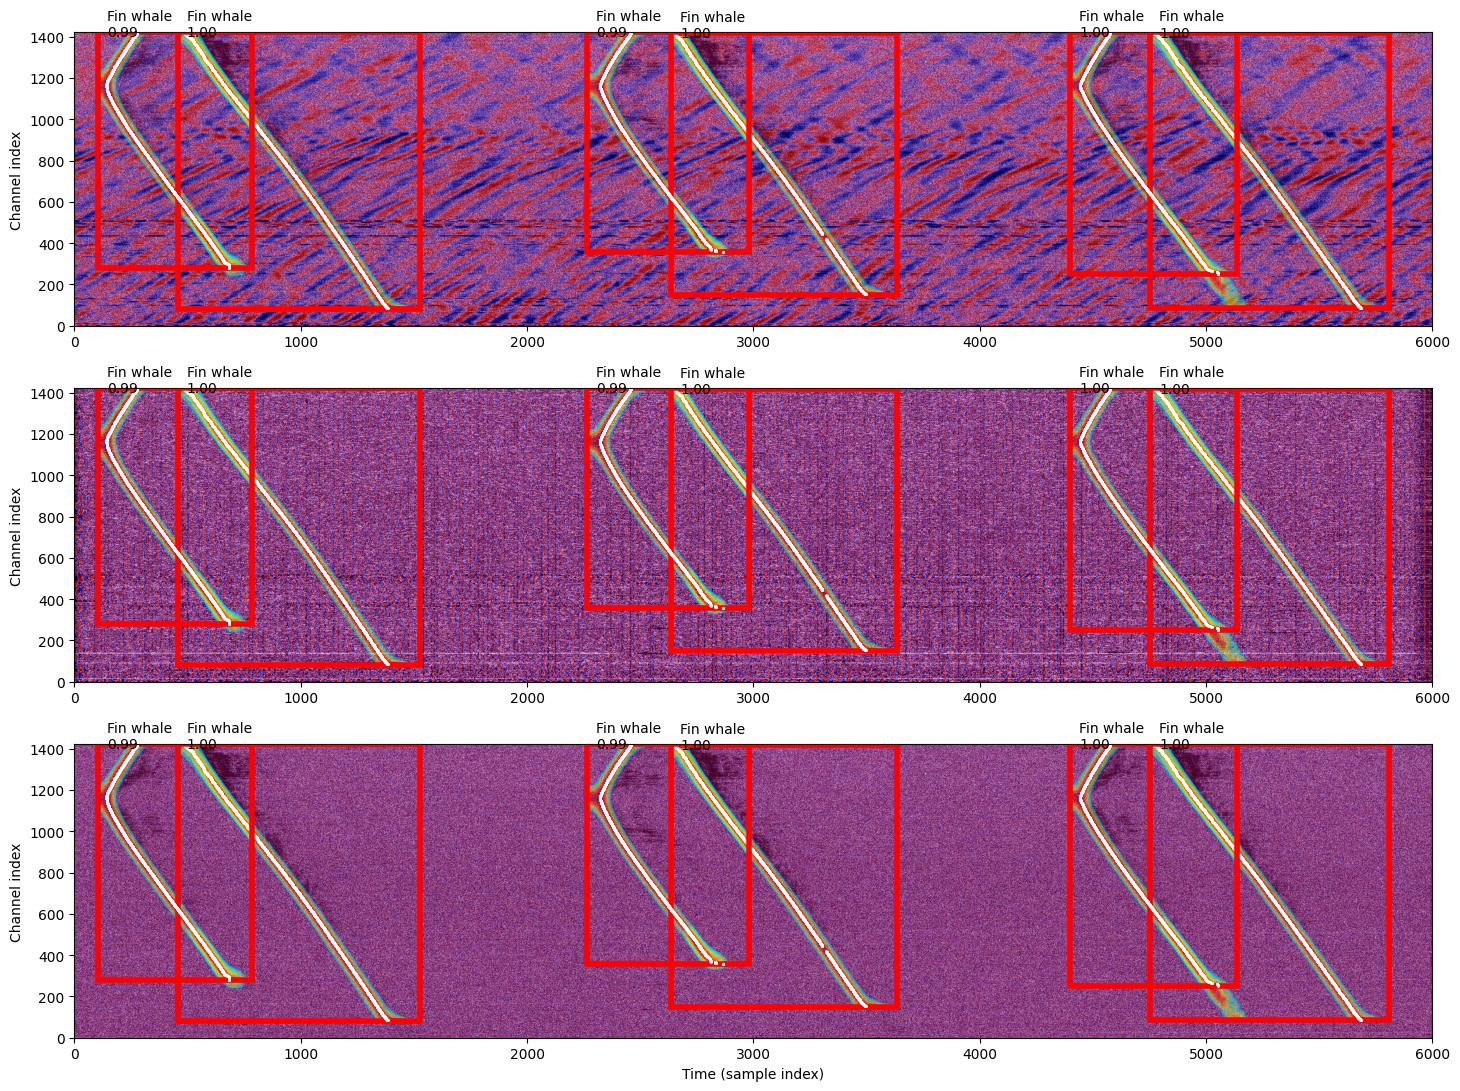

{
  "file_name": "20231109T132510Z.h5",
  "resize_scale": 0.5,
  "instances": [
    {
      "box": [
        164.8438720703125,
        914.1192626953125,
        2843.15625,
        3053.880859375
      ],
      "score": 0.9995997548103333,
      "label": 3,
      "label_name": "Fin whale",
      "picks": [
        [
          168.0,
          2770.0
        ],
        [
          170.0,
          2768.0
        ],
        [
          172.0,
          2766.0
        ],
        [
          174.0,
          2762.0
        ],
        [
          176.0,
          2760.0
        ],
        "... (1338 total)"
      ],
      "pick_scores": [
        0.529354989528656,
        0.5951864719390869,
        0.6569203734397888,
        0.7130587100982666,
        0.7625828981399536,
        "... (1338 total)"
      ]
    },
    {
      "box": [
        167.2171630859375,
        9504.1396484375,
        2840.78271484375,
        11615.8603515625
      ],
      "score": 0.9994791150093079,
      "

In [16]:
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print("No figure at", fig_path)

json_path = RESULT_DIR / (Path(fn0).stem + ".json")
with open(json_path) as f:
    payload = json.load(f)

view = json.loads(json.dumps(payload))
for inst in view.get("instances", []):
    for key in ("picks", "pick_scores"):
        if key in inst and len(inst[key]) > 5:
            n = len(inst[key])
            inst[key] = inst[key][:5] + [f"... ({n} total)"]

print(json.dumps(view, indent=2))


## Optional: predict.py from the command line

The same end-to-end inference is available as a script. Edit **CLI_EVENT_IDS** (one or more compact UTC IDs), download each file with **hf_hub_download**, write a **data_list.csv** with a `path` column, and run **predict.py** once. Outputs go to **pred_cli/** (JSON + **figures_dasnet/**).

The following cell shows quicklook figures in **data_list.csv** order. Set **FIG_PREVIEW_N** to **None** for all rows, or a positive integer for only the **first n**.


In [17]:
from tqdm.auto import tqdm

HF_REPO_BATCH = "AI4EPS/quakeflow_das"
CLI_LOCAL_DIR = Path(WORK_DIR) / "data" / "quakeflow_das"

CLI_EVENT_IDS = [
    "20231116T130210Z",
    "20231110T105410Z",
    "20231124T104510Z",
    "20231130T194610Z",
    "20240204T004410Z",
    "20240428T100822Z",
    "20220828T062358Z",
    "20220828T140758Z",
    "20230407T074209Z",
]

pred_cli = Path(WORK_DIR) / "pred_cli"
pred_cli.mkdir(parents=True, exist_ok=True)
csv_path = pred_cli / "data_list.csv"

paths_for_cli = []
for eid in tqdm(CLI_EVENT_IDS, desc="HF fetch (batch)", unit="file"):
    p = hf_hub_download(
        HF_REPO_BATCH,
        f"monterey_bay/data/{eid}.h5",
        repo_type="dataset",
        local_dir=str(CLI_LOCAL_DIR),
    )
    paths_for_cli.append(str(Path(p).resolve()))

with open(csv_path, "w", newline="") as fp:
    w = csv.writer(fp)
    w.writerow(["path"])
    for p in paths_for_cli:
        w.writerow([p])

print(f"data_list.csv: {len(paths_for_cli)} rows -> {csv_path.resolve()}")

predict_py = Path(WORK_DIR) / "predict.py"
base = [
    str(predict_py),
    "--model",
    "dasnet",
    "--resume",
    str(CKPT_PATH),
    "--data_list",
    str(csv_path),
    "--batch_size",
    "1",
    "--min_prob",
    str(MIN_PROB),
    "--result_path",
    str(pred_cli),
    "--plot_figure",
    "--workers",
    "0",
]
if DEVICE.type == "cpu":
    cmd = ["python"] + base + ["--device", "cpu"]
else:
    cmd = ["python"] + base

print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, cwd=str(WORK_DIR), capture_output=True, text=True)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr)
proc.check_returncode()

n_json = len(list(pred_cli.glob("*.json")))
print(f"Finished. JSON count under pred_cli: {n_json}")


HF fetch (batch):   0%|          | 0/9 [00:00<?, ?file/s]

monterey_bay/data/20231116T130210Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

monterey_bay/data/20231110T105410Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

monterey_bay/data/20231124T104510Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

monterey_bay/data/20231130T194610Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

...

monterey_bay/data/20240428T100822Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

monterey_bay/data/20220828T062358Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

monterey_bay/data/20220828T140758Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

monterey_bay/data/20230407T074209Z.h5:   0%|          | 0.00/137M [00:00<?, ?B/s]

data_list.csv: 9 rows -> /content/DASNet-workshop/DASNet-workshop/pred_cli/data_list.csv
Running: python /content/DASNet-workshop/DASNet-workshop/predict.py --model dasnet --resume /content/DASNet-workshop/DASNet-workshop/checkpoint.pth --data_list /content/DASNet-workshop/DASNet-workshop/pred_cli/data_list.csv --batch_size 1 --min_prob 0.8 --result_path /content/DASNet-workshop/DASNet-workshop/pred_cli --plot_figure --workers 0
Not using distributed mode
Namespace(model='dasnet', resume='/content/DASNet-workshop/DASNet-workshop/checkpoint.pth', device='cuda', batch_size=1, workers=0, amp=False, distributed=False, world_size=1, dist_url='env://', data_list='/content/DASNet-workshop/DASNet-workshop/pred_cli/data_list.csv', object='default', key_path=None, result_path='/content/DASNet-workshop/DASNet-workshop/pred_cli', min_prob=0.8, plot_figure=True, skip_existing=False, use_deterministic_algorithms=False)
Total file number from list: 9
Loading checkpoint: /content/DASNet-workshop/DASNe

Showing 9 of 9 data_list.csv row(s) (FIG_PREVIEW_N=None).
[1/9] 20231116T130210Z.h5


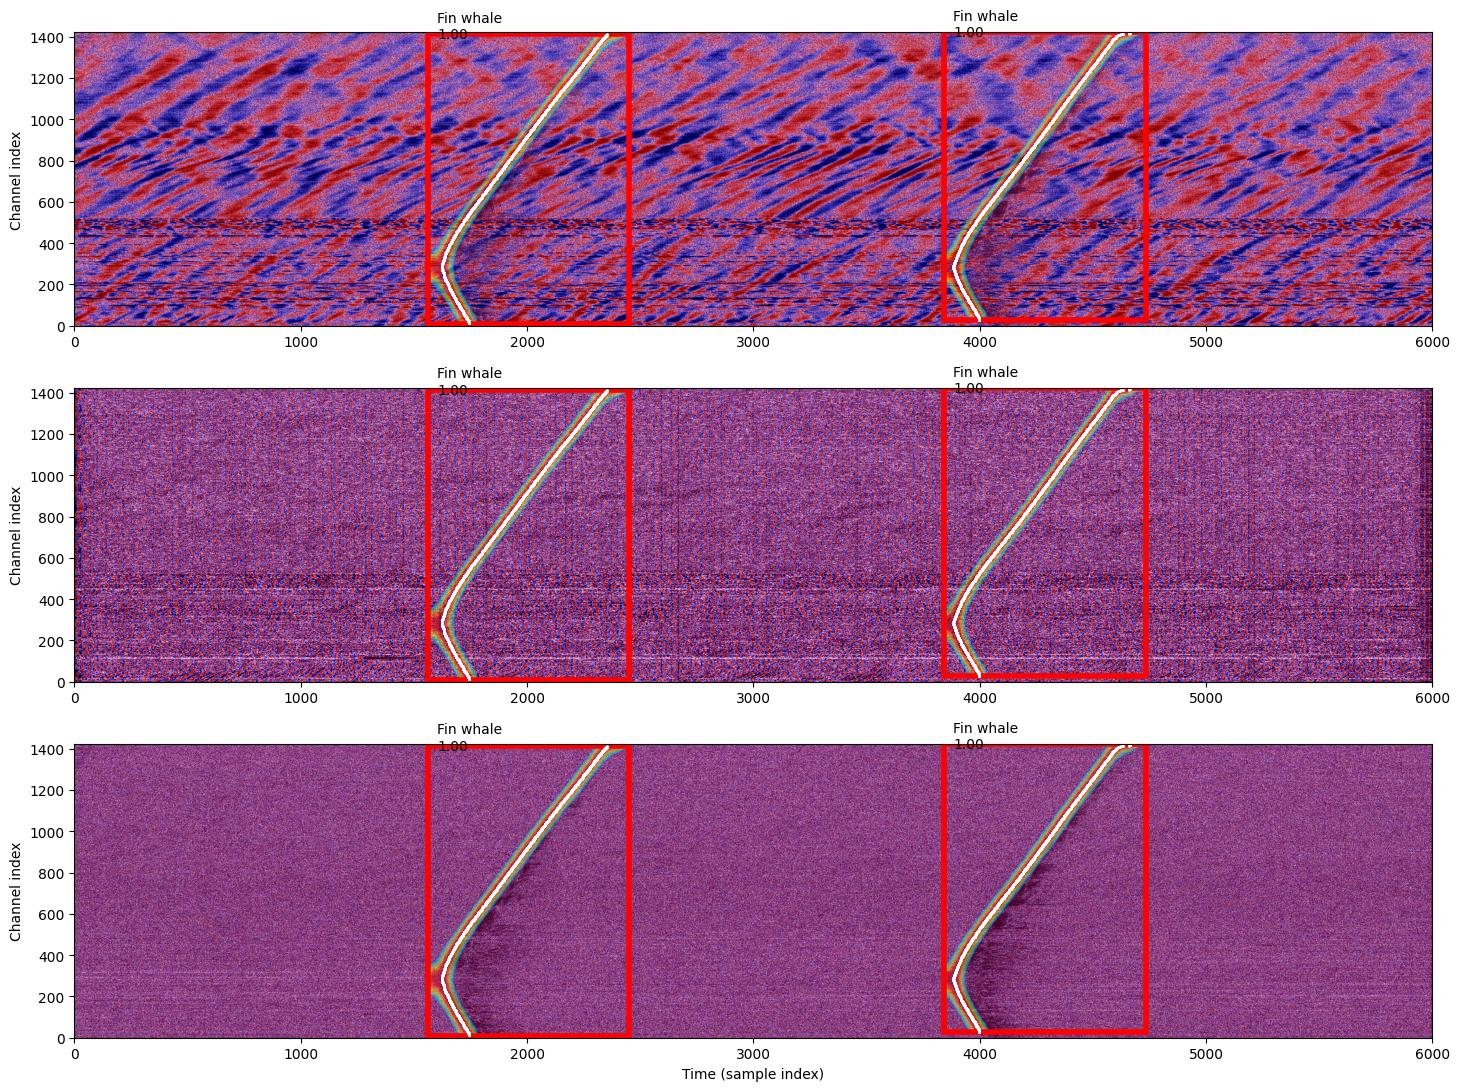

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20231116T130210Z.h5.jpg

[2/9] 20231110T105410Z.h5


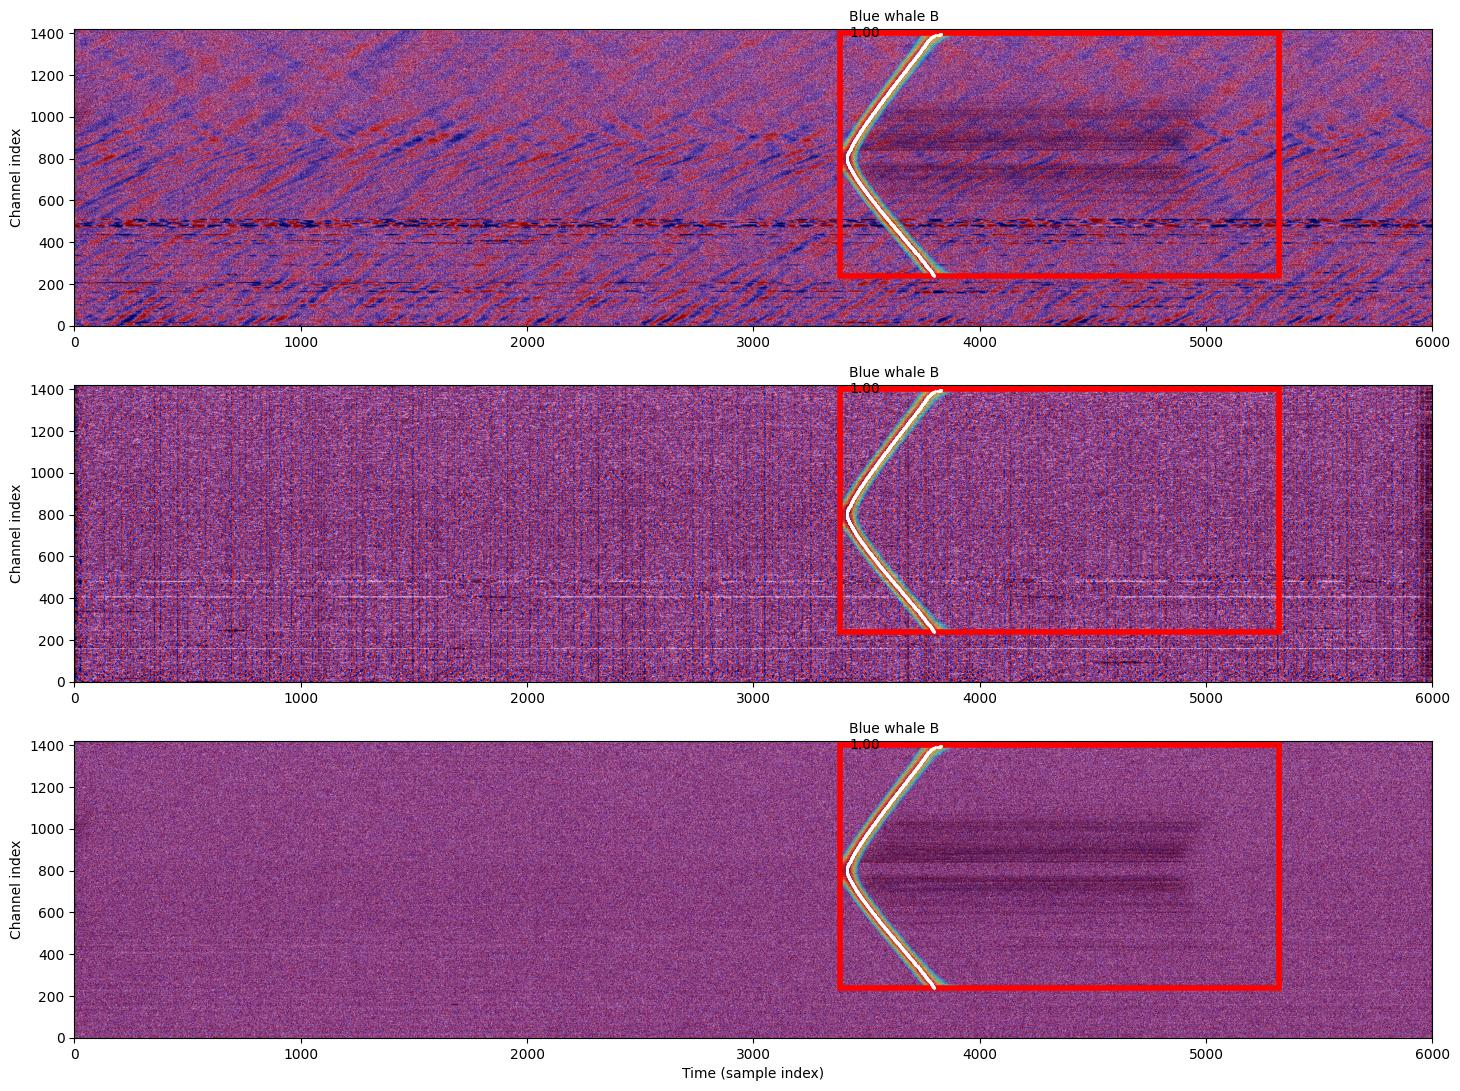

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20231110T105410Z.h5.jpg

[3/9] 20231124T104510Z.h5


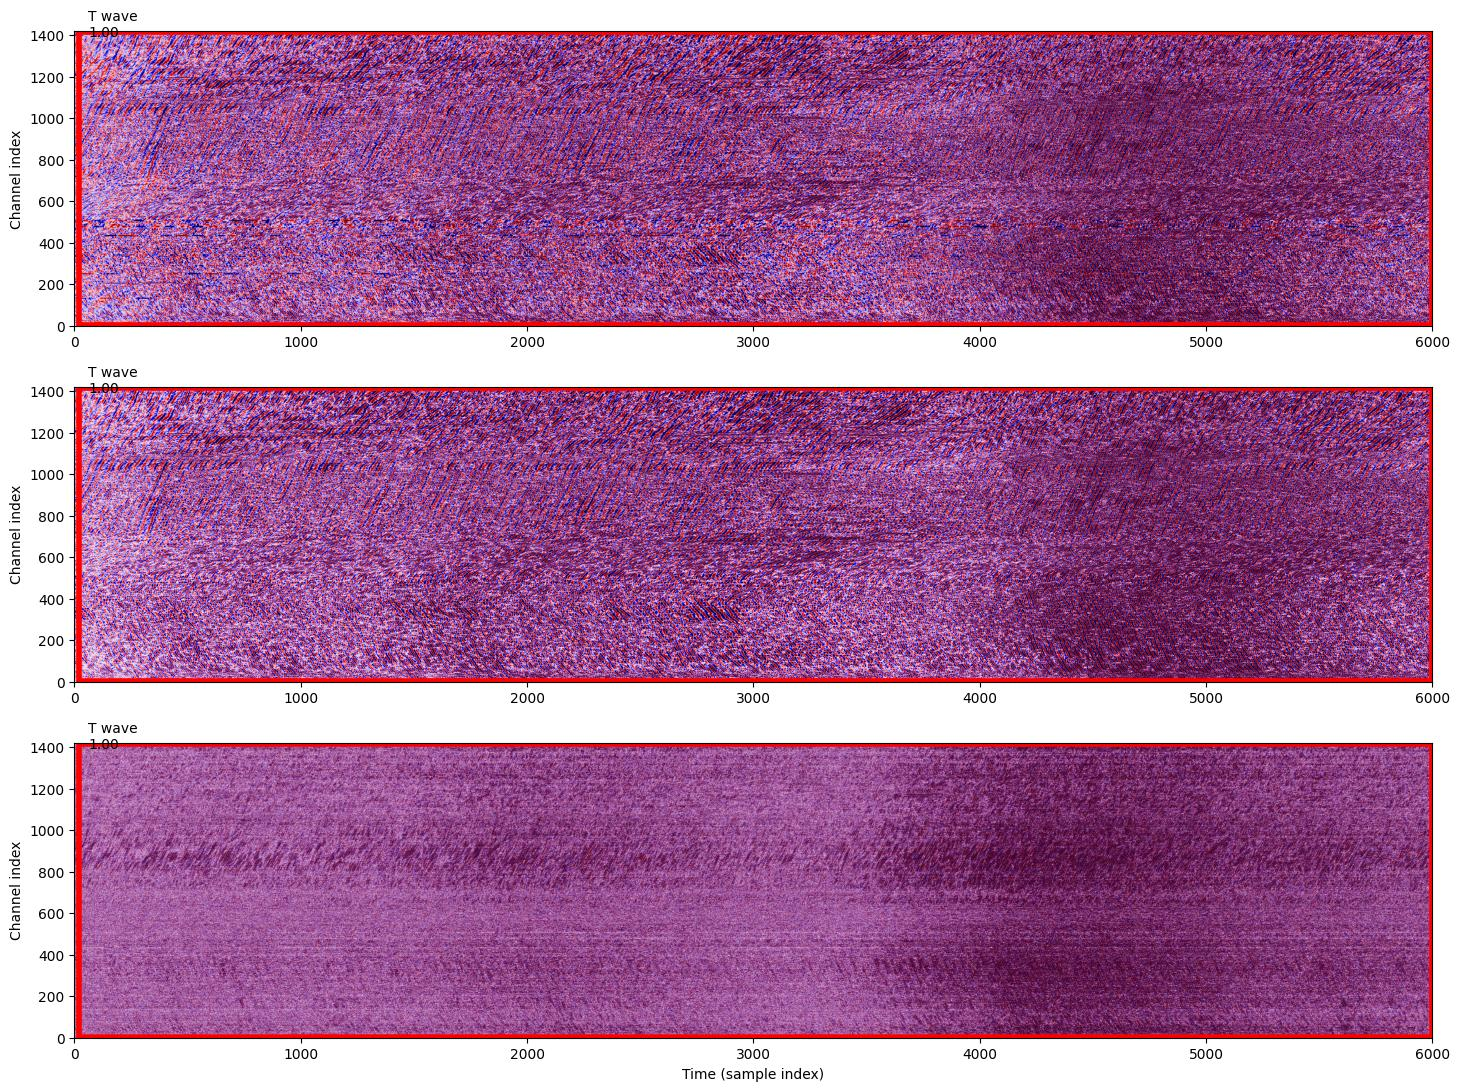

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20231124T104510Z.h5.jpg

[4/9] 20231130T194610Z.h5


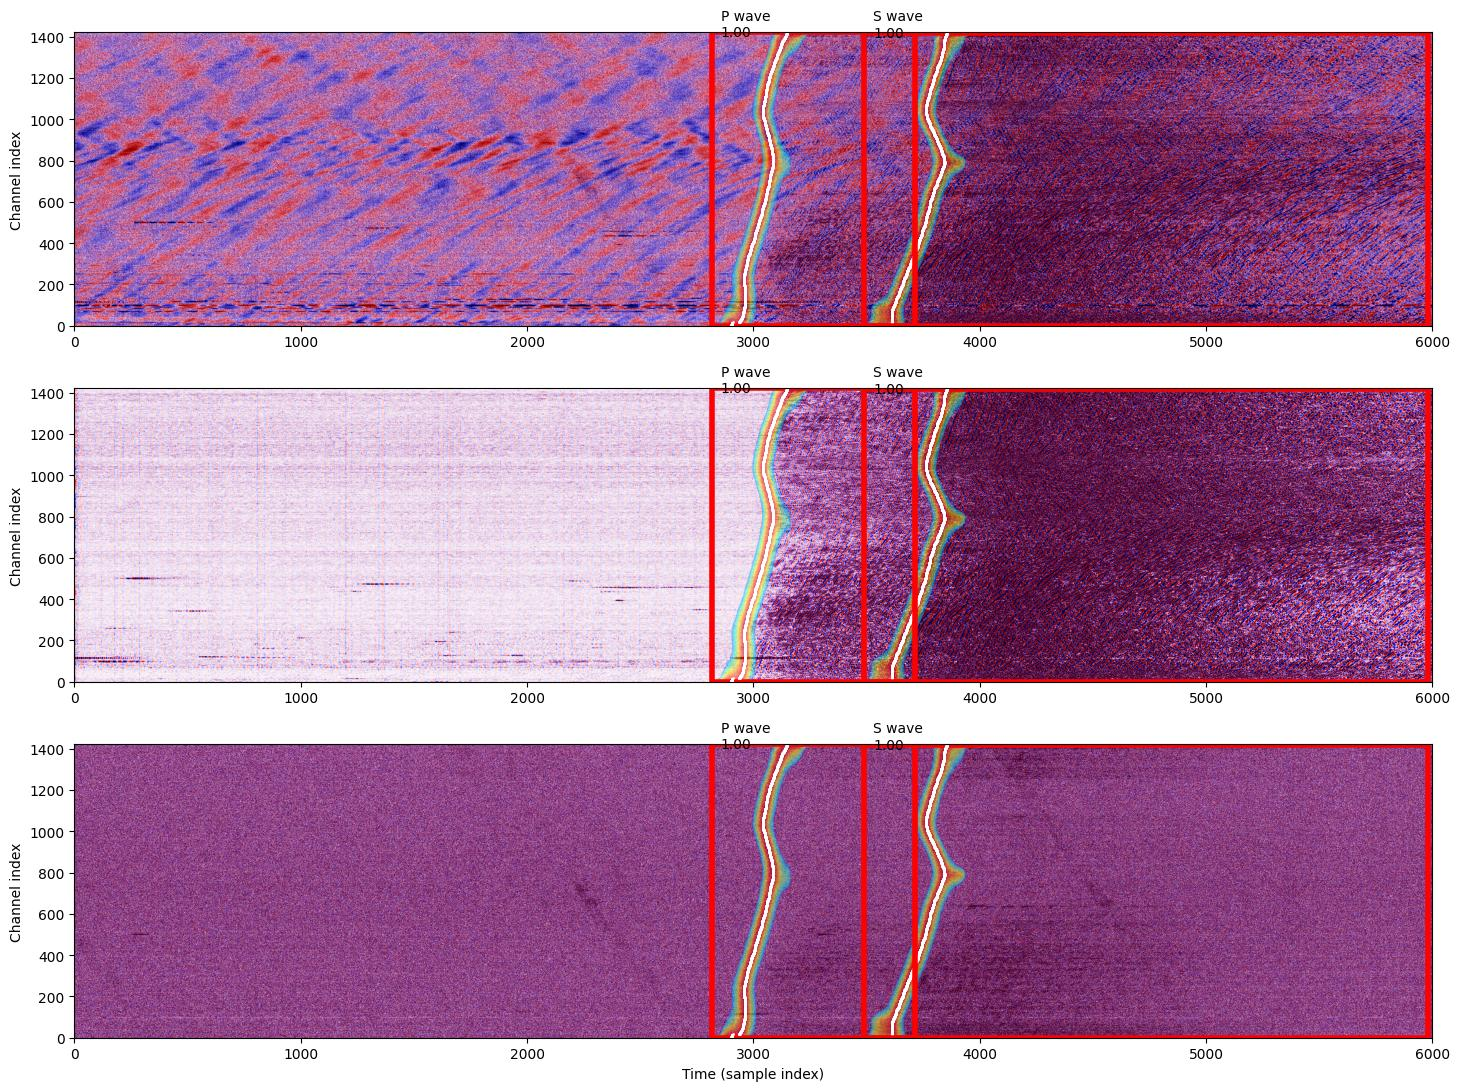

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20231130T194610Z.h5.jpg

[5/9] 20240204T004410Z.h5


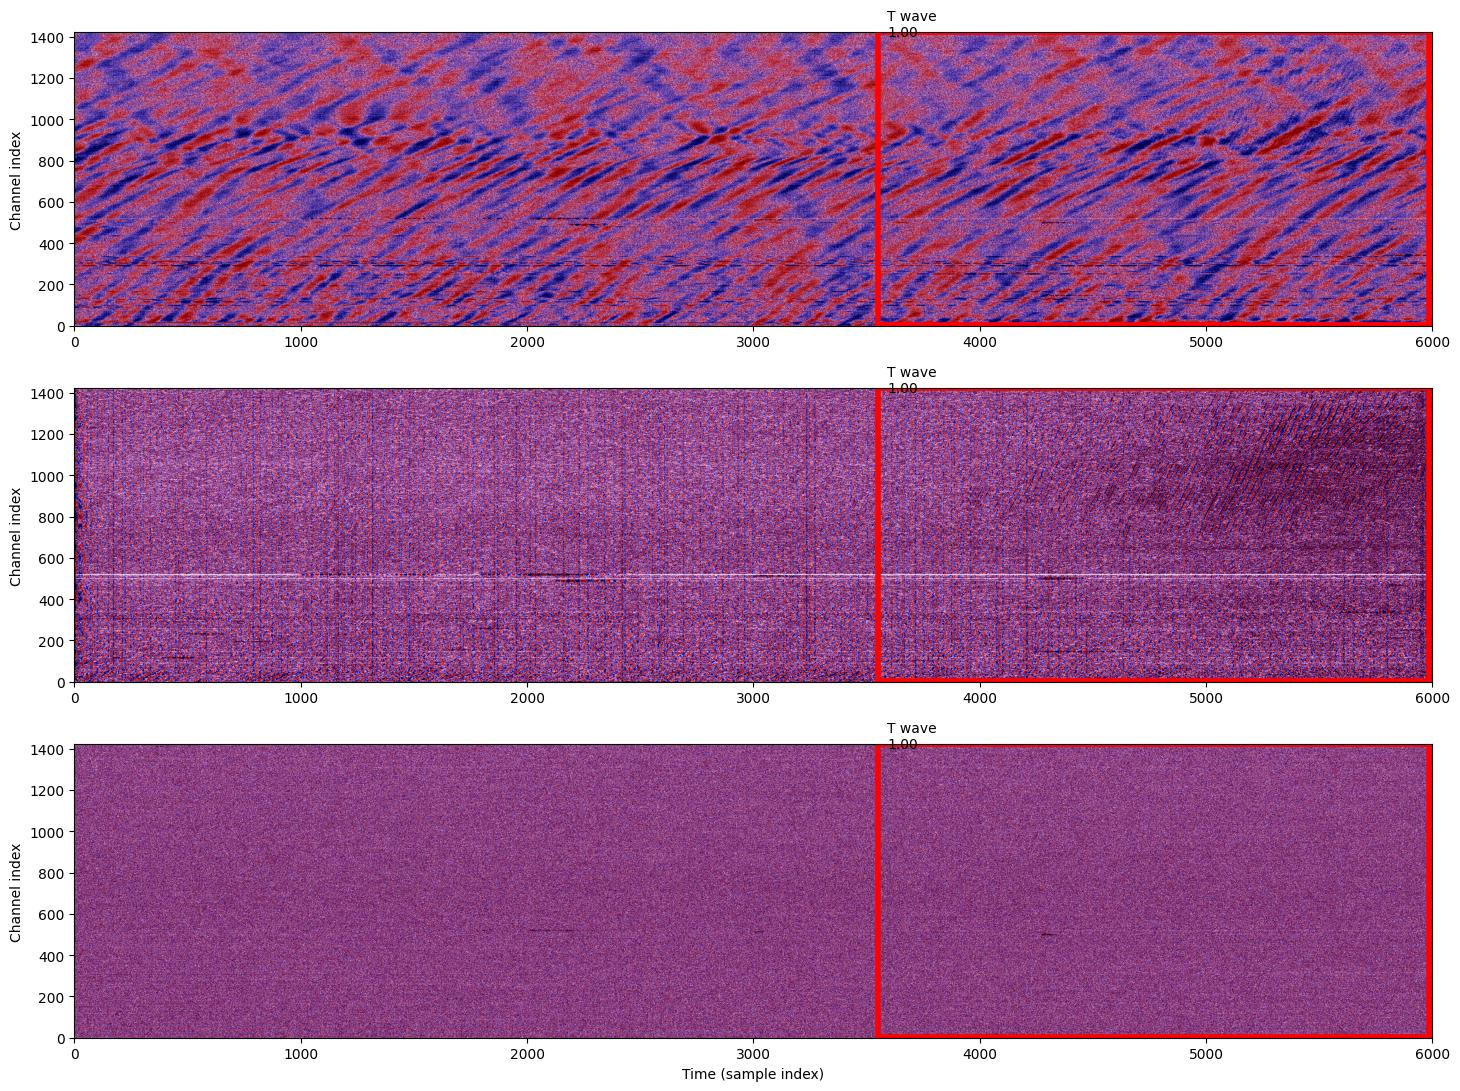

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20240204T004410Z.h5.jpg

[6/9] 20240428T100822Z.h5


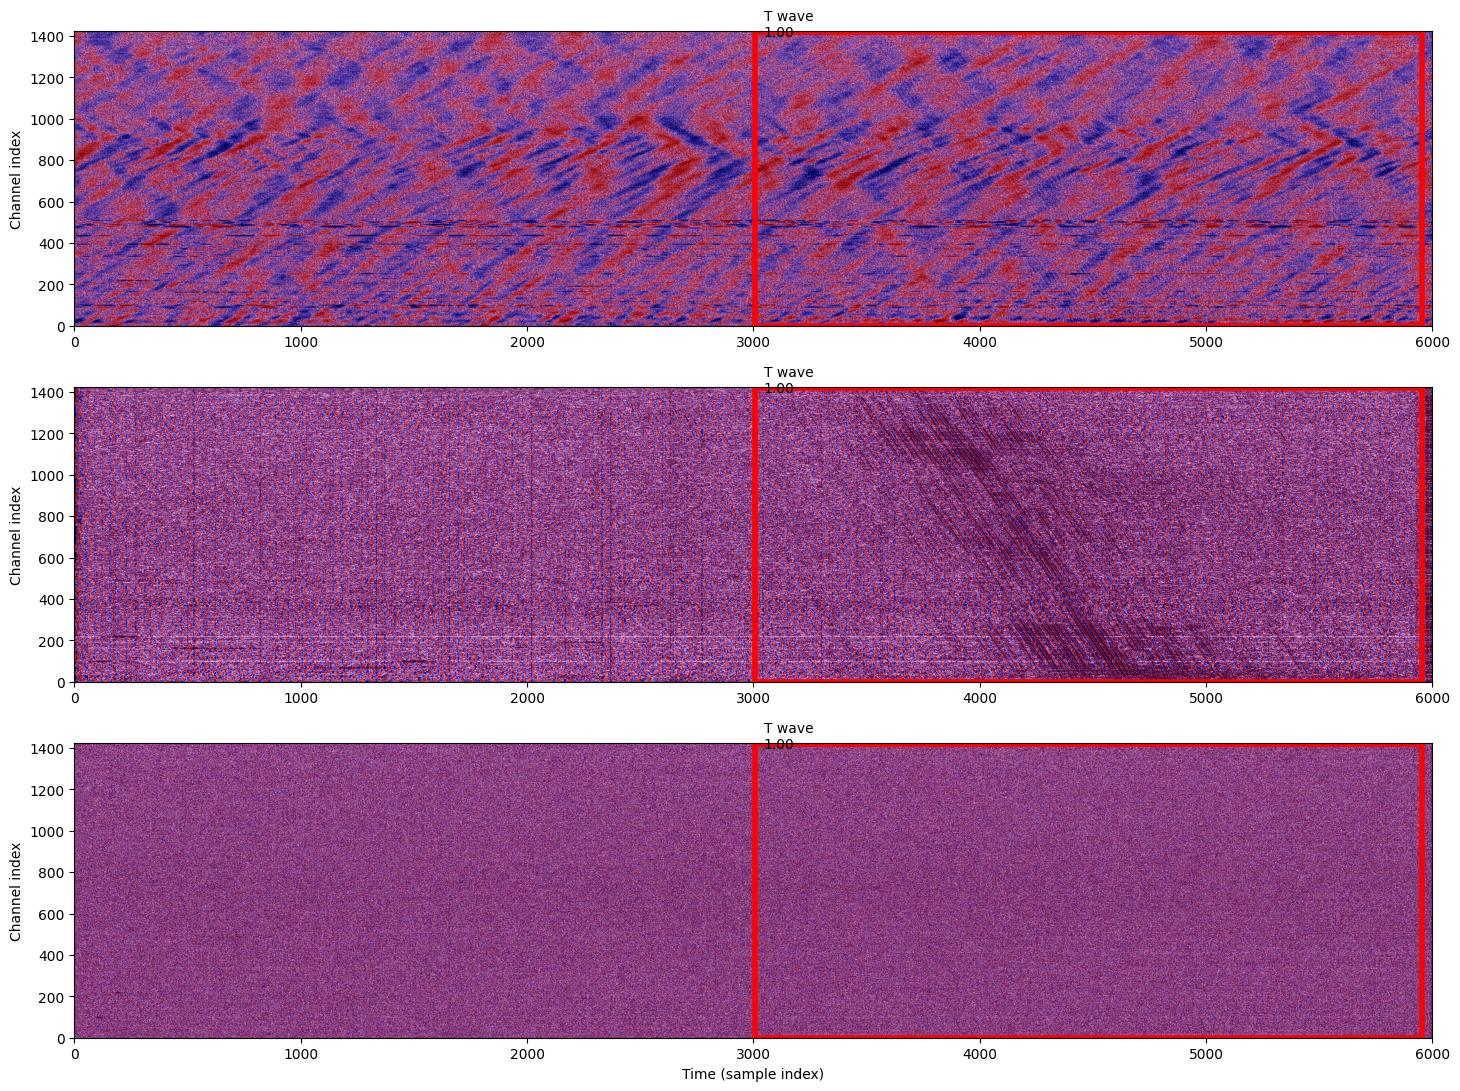

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20240428T100822Z.h5.jpg

[7/9] 20220828T062358Z.h5


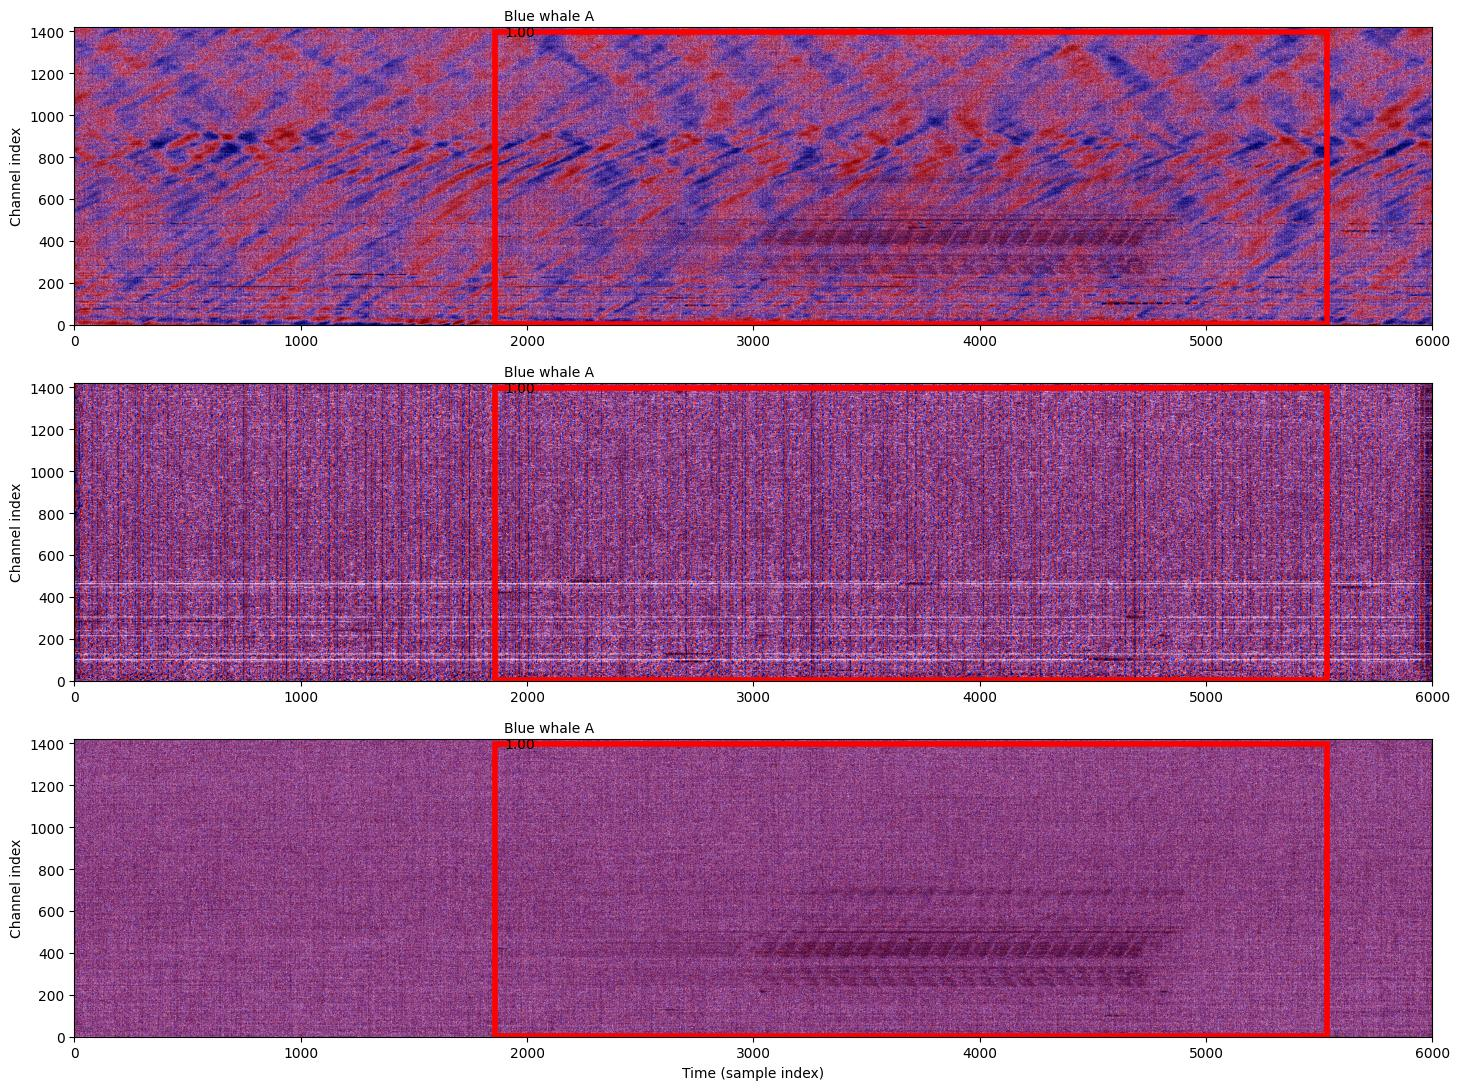

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20220828T062358Z.h5.jpg

[8/9] 20220828T140758Z.h5


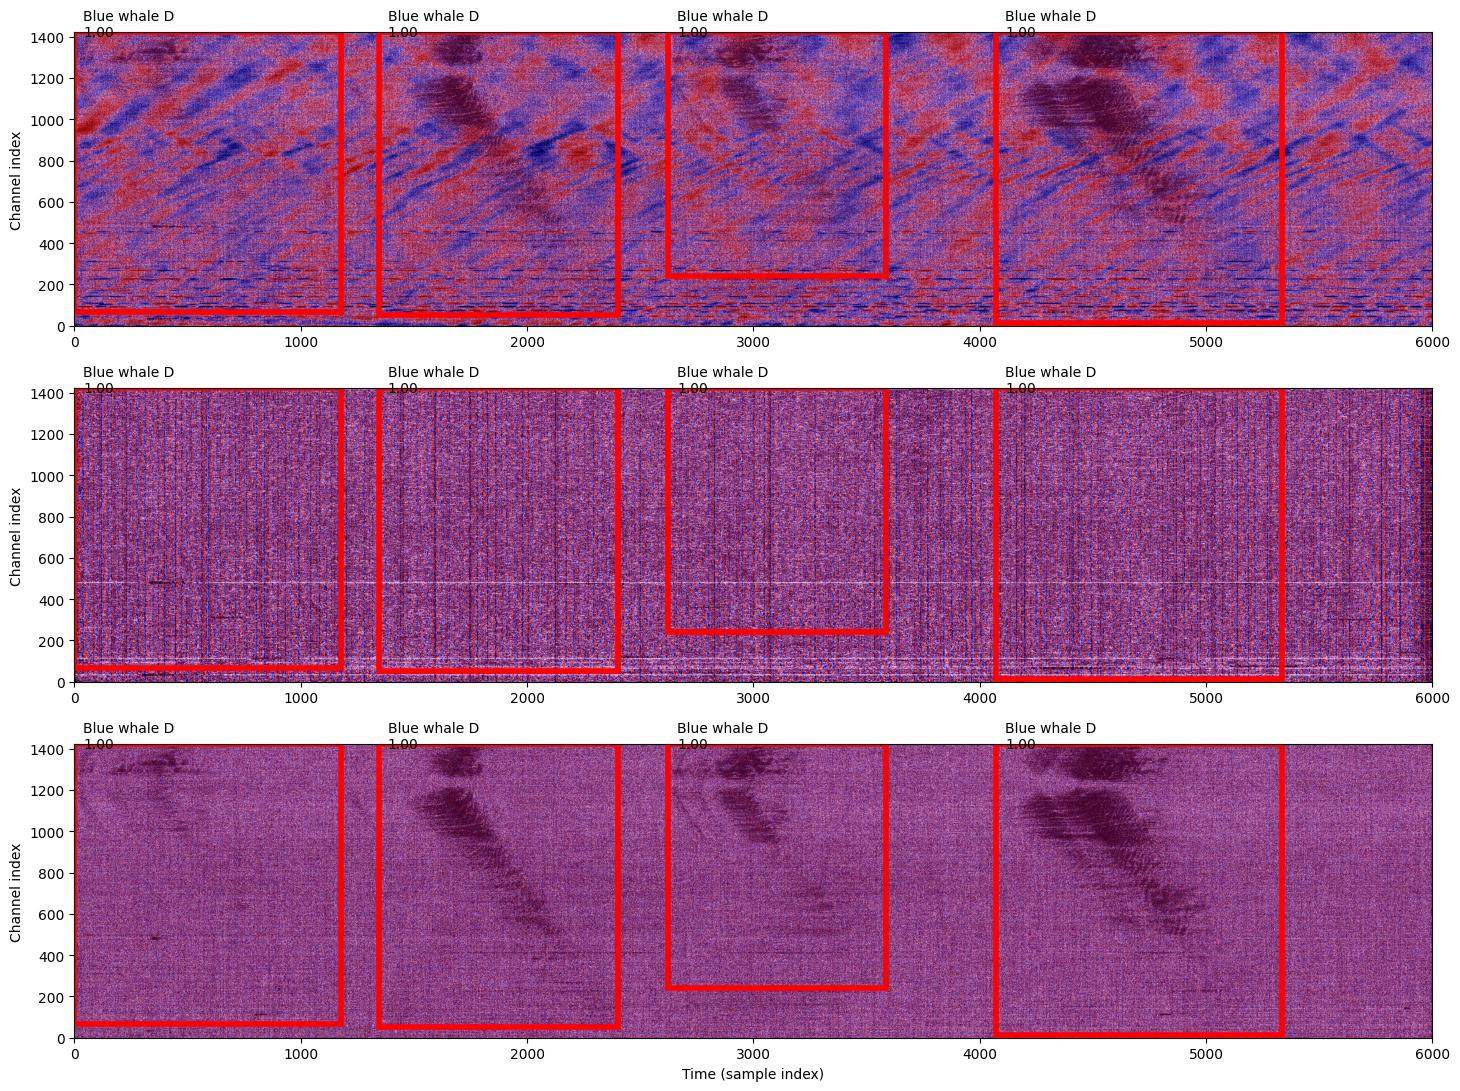

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20220828T140758Z.h5.jpg

[9/9] 20230407T074209Z.h5


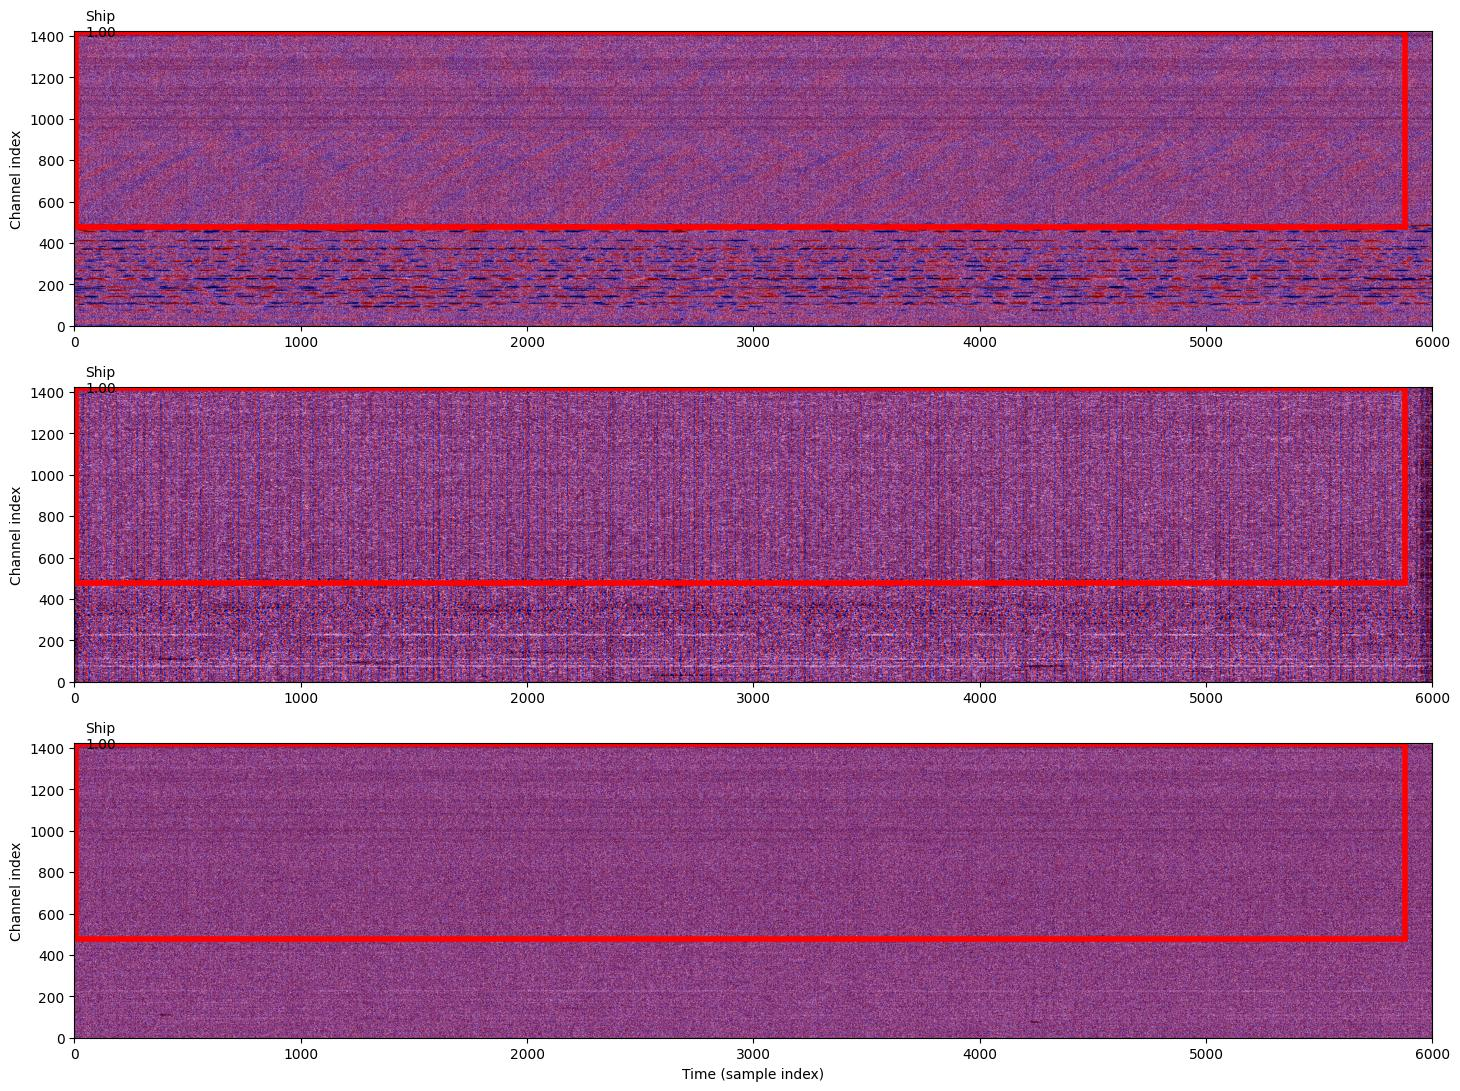

/content/DASNet-workshop/DASNet-workshop/pred_cli/figures_dasnet/20230407T074209Z.h5.jpg



In [18]:
FIG_PREVIEW_N = None  # None = show all CSV rows; set int n to show only the first n

pred_cli = Path(WORK_DIR) / "pred_cli"
cli_fig_dir = pred_cli / "figures_dasnet"

with open(pred_cli / "data_list.csv", newline="") as fp:
    rows_all = list(csv.DictReader(fp))
if not rows_all:
    raise FileNotFoundError("Run the previous cell first (data_list.csv missing or empty).")

if FIG_PREVIEW_N is None:
    rows = rows_all
else:
    rows = rows_all[: max(0, int(FIG_PREVIEW_N))]

n_all = len(rows_all)
n = len(rows)
print(f"Showing {n} of {n_all} data_list.csv row(s) (FIG_PREVIEW_N={FIG_PREVIEW_N!r}).")

for i, row in enumerate(rows):
    h5_name = Path(row["path"]).name
    fig_path = cli_fig_dir / (h5_name + ".jpg")
    print(f"[{i + 1}/{n}] {h5_name}")
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
        print(fig_path.resolve())
    else:
        print("  (figure missing)", fig_path.resolve())
    print()
